# SMELL VISUALIZATION (Under construction)

# Objectives

Upon completing this tutorial, you will be able to adjust the valence of an Interactional Motivation (IM) system to design an agent that generates pray or flee behavior.

See the full tutorial at https://github.com/PetiteIA/schema_mechanism

See Interactional Motivation in AIRIS at [interactional_motivation.md](interactional_motivation.md).

# Let's implement the agent

In [2]:
class CompositeInteraction:
    """A composite interaction is a tuple (pre_interaction, post_interaction) and a weight"""
    def __init__(self, pre_interaction, post_interaction):
        self.pre_interaction = pre_interaction
        self.post_interaction = post_interaction
        self.weight = 1
        self._step = 1

    def get_decision(self):
        """Return the flatten sequence of intermediary primitive interactions terminated with the final decision"""
        return f"{self.pre_interaction.sequence()}{self.post_interaction.get_decision()}"

    def get_actions(self):
        """Return the flat sequence of the decisions of this interaction as a string"""
        return f"{self.pre_interaction.get_actions()}{self.post_interaction.get_actions()}"

    def get_valence(self):
        """Return the valence of the pre_interaction plus the valence of the post_interaction"""
        return self.pre_interaction.get_valence() + self.post_interaction.get_valence()

    def reinforce(self):
        """Increment the composite interaction's weight"""
        self.weight += 1

    def key(self):
        """ The key to find this interaction in the dictionary is the string '<pre_interaction><post_interaction>'. """
        return f"({self.pre_interaction.key()},{self.post_interaction.key()})"

    def pre_key(self):
        """Return the key of the pre_interaction"""
        #if self.weight > confidence_threshold:
        return self.pre_interaction.key()
        #else:
        #return self.pre_interaction.pre_key()

    def __str__(self):
        """ Print the interaction in the Newick tree format (pre_interaction, post_interaction: valence) """
        return f"({self.pre_interaction}, {self.post_interaction}: {self.weight})"

    def __eq__(self, other):
        """ Interactions are equal if they have the same pre and post interactions """
        if isinstance(other, self.__class__):
            return (self.pre_interaction == other.pre_interaction) and (self.post_interaction == other.post_interaction)
        else:
            return False

    def get_length(self):
        """Return the length of the number of primitive interactions in this composite interaction"""
        return self.pre_interaction.get_length() + self.post_interaction.get_length()

    def increment(self, interaction, interactions):
        """Increment the step of the appropriate sub-interaction. Return the enacted interaction if it is over, or None if it is ongoing."""
        # First step 
        if self._step == 1:
            interaction = self.pre_interaction.increment(interaction, interactions)
            # Ongoing pre-interaction. Return None
            if interaction is None:
                return None
            # Pre-interaction succeeded. Increment the step and return None
            elif interaction == self.pre_interaction:
                self._step = 2
                return None
            # Pre-interaction failed. Reset the step and return the enacted interaction
            else:
                self._step = 1
                return interaction
        # Second step
        else:
            interaction = self.post_interaction.increment(interaction, interactions)
            # Ongoing post-interaction. Return None
            if interaction is None:
                return None
            # Post-interaction succeeded. Reset the step and return this interaction
            elif interaction == self.post_interaction:
                self._step = 1
                return self
            # Post-interaction failed. Reset the step and return the enacted interaction
            else:
                self._step = 1
                composite_interaction = CompositeInteraction(self.pre_interaction, interaction)
                if composite_interaction.key() not in interactions:
                    # Add the enacted composite interaction to memory
                    interactions[composite_interaction.key()] = composite_interaction
                    if trace:
                        print(f"Learning {composite_interaction}")
                    return composite_interaction
                else:
                    # Reinforce the existing composite interaction and return it
                    interactions[composite_interaction.key()].reinforce()
                    if trace:
                        print(f"Reinforcing {interactions[composite_interaction.key()]}")
                    return interactions[composite_interaction.key()]

    def current(self):
        """Return the current intended primitive interaction"""
        # Step 1: the current primitive interaction of the pre-interaction
        if self._step == 1:
            return self.pre_interaction.current()
        # Step 2: The current primitive interaction of the post-interaction
        else:
            return self.post_interaction.current()

    def sequence(self):
        """Return the flat sequence of primitive interactions of this composite interaction"""
        return f"{self.pre_interaction.sequence()}{self.post_interaction.sequence()}"

    def get_post_interactions(self):
        """Return the list of the hierarchy of the sub post_interactions"""
        return [self.post_interaction] + self.post_interaction.get_post_interactions()

In [3]:
class Interaction:
    """An interaction is a tuple (action, outcome) with a valence"""
    def __init__(self, _action, _outcome, _valence):
        self._action = _action
        self._outcome = _outcome
        self._valence = _valence
        self.weight = 10
        
    def get_action(self):
        """Return the action"""
        return self._action

    def get_actions(self):
        """Return the action as a string for compatibilty with CompositeInteraction"""
        return str(self._action)

    def get_decision(self):
        """Return the decision key"""
        return f"{self._action}"
        # return f"a{self._action}"

    def get_outcome(self):
        """Return the action"""
        return self._outcome

    def get_valence(self):
        """Return the action"""
        return self._valence

    def key(self):
        """ The key to find this interaction in the dictinary is the string '<action><outcome>'. """
        return f"{self._action}{self._outcome}"

    def pre_key(self):
        """Return the key. Used for compatibility with CompositeInteraction"""
        return ""  # self.key()

    def __str__(self):
        """ Print interaction in the form '<action><outcome:<valence>' for debug."""
        return f"{self._action}{self._outcome}:{self._valence}"

    def __eq__(self, other):
        """ Interactions are equal if they have the same key """
        if isinstance(other, self.__class__):
            return self.key() == other.key()
        else:
            return False

    def get_length(self):
        """The length of the sequence of this interaction"""
        return 1

    def increment(self, interaction, interactions):
        """Return the enacted interaction for compatibility with composite interactions"""
        return interaction

    def current(self):
        """Return itself for compatibility with composite interactions"""
        return self

    def sequence(self):
        """Return the key. Use for compatibility with composite interactions"""
        return self.key()

    def get_post_interactions(self):
        """Return the empty list for compatibility with composite interactions"""
        return []

In [4]:
trace = True
# Maximum length of intended sequence
max_length = 5
# Minimum weight of intended sequence
min_weight = 1

In [5]:
import pandas as pd

class Agent:
    def __init__(self, _interactions):
        """ Initialize our agent """
        self._interactions = {interaction.key(): interaction for interaction in _interactions}
        self._primitive_intended_interaction = self._interactions["00"]
        self._intended_interaction = None

        # The context
        self._penultimate_interaction = None
        self._previous_interaction = None
        self._last_interaction = None
        self._penultimate_composite_interaction = None
        self._previous_composite_interaction = None
        self._last_composite_interaction = None
        
        # Prepare the dataframe of proposed interactions
        default_interactions = [interaction for interaction in _interactions if interaction.get_outcome() == 0]
        data = {'activated': [""] * len(default_interactions),
                'weight': [0] * len(default_interactions),
                'actions': [i.get_actions() for i in default_interactions],
                'intention': [i.key() for i in default_interactions],
                'valence': [i.get_valence() for i in default_interactions],
                'decision': [i.get_decision() for i in default_interactions],
                'length': [1] * len(default_interactions),
                'pre': [""] * len(default_interactions)} 
        self._default_df = pd.DataFrame(data)
        self.proposed_df = None
        self.decision_df = None
        self.clear = True # Used to clear the display after the enacted interaction

    def action(self, _outcome):
        """Implement the agent's policy"""
        # Trace the previous cycle
        primitive_enacted_interaction = self._interactions[f"{self._primitive_intended_interaction.get_action()}{_outcome}"]
        if trace:
            print(
            f"Action: {self._primitive_intended_interaction.get_action()}, Prediction: {self._primitive_intended_interaction.get_outcome()}, "
            f"Outcome: {_outcome}, Prediction_correct: {self._primitive_intended_interaction.get_outcome() == _outcome}, "
            f"Valence: {primitive_enacted_interaction.get_valence()}")

        # Follow up the enaction
        if self._intended_interaction is None: # First interaction cycle
            enacted_interaction = primitive_enacted_interaction
        else:
            enacted_interaction = self._intended_interaction.increment(primitive_enacted_interaction, self._interactions)

        # If the intended interaction is over (completely enacted or aborted)
        if enacted_interaction is None:
            self.clear = False
        else:
            self.clear = True
            # Memorize the context
            self._penultimate_composite_interaction = self._previous_composite_interaction
            self._previous_composite_interaction = self._last_composite_interaction
            self._penultimate_interaction = self._previous_interaction
            self._previous_interaction = self._last_interaction
            self._last_interaction = enacted_interaction
            # Call the learning mechanism
            self.learn(enacted_interaction)
            # Create the proposed dataframe
            self.create_proposed_df()
            self.aggregate_propositions()
            # Decide the next enaction
            self.decide()

        # Return the next primitive action
        self._primitive_intended_interaction = self._intended_interaction.current()
        return self._primitive_intended_interaction.get_action()
        
    def learn(self, enacted_interaction):
        """Learn the composite interactions"""
        # First level of composite interactions
        self._last_composite_interaction = self.learn_composite_interaction(self._previous_interaction, enacted_interaction)
        # Second level of composite interactions
        self.learn_composite_interaction(self._previous_composite_interaction, enacted_interaction)
        self.learn_composite_interaction(self._penultimate_interaction, self._last_composite_interaction)

        # Higher level composite interaction made of two composite interactions
        if self._last_composite_interaction is not None:
            self.learn_composite_interaction(self._penultimate_composite_interaction, self._last_composite_interaction)

    def learn_composite_interaction(self, pre_interaction, post_interaction):
        """Record or reinforce the composite interaction made of (pre_interaction, post_interaction)"""
        if pre_interaction is None:
            return None
        else:
            # If the pre-interaction exists
            composite_interaction = CompositeInteraction(pre_interaction, post_interaction)
            if composite_interaction.key() not in self._interactions:
                # Add the composite interaction to memory
                self._interactions[composite_interaction.key()] = composite_interaction
                if trace:
                    print(f"Learning {composite_interaction}")
                return composite_interaction
            else:
                # Reinforce the existing composite interaction and return it
                self._interactions[composite_interaction.key()].reinforce()
                if trace:
                    print(f"Reinforcing {self._interactions[composite_interaction.key()]}")
                return self._interactions[composite_interaction.key()]

    def create_proposed_df(self):
        """Create the proposed dataframe from the activated interactions"""
        # The list of activated interactions that match the current context
        activated_interactions = [i for i in self._interactions.values() if i.get_length() > 1 
                                  and i.pre_interaction in self._last_composite_interaction.get_post_interactions()]
        data = {'activated': [i.key() for i in activated_interactions],
                'weight': [i.weight for i in activated_interactions],
                'actions': [i.post_interaction.get_actions() for i in activated_interactions],
                'intention': [i.post_interaction.key() for i in activated_interactions],
                'valence': [i.post_interaction.get_valence() for i in activated_interactions],
                'decision': [i.post_interaction.get_decision() for i in activated_interactions],
                'pre': [i.post_interaction.pre_key() for i in activated_interactions],
                'length': [i.post_interaction.get_length() for i in activated_interactions],
                }
        activated_df = pd.DataFrame(data).astype(self._default_df.dtypes)  # Force the same types in case activated_df is empty

        # Create the proposed dataframe
        self.proposed_df = pd.concat([self._default_df, activated_df], ignore_index=True).sort_values(by='decision', ascending=True).reset_index(drop=True)

        # Calculate the proclivity of each proposition
        self.proposed_df['proclivity'] = self.proposed_df['weight'] * self.proposed_df['valence']

        # Compute the probability of each propositions
        # self.proposed_df['probability'] = self.proposed_df['weight'] / self.proposed_df.groupby('actions')['weight'].transform('sum')
        # self.proposed_df['probability'] = self.proposed_df.groupby('intention')['weight'].transform('sum') / self.proposed_df.groupby('actions')['weight'].transform('sum')

    def aggregate_propositions(self):
        """Aggregate the proclivity"""
        # Aggregate the proclivity for each decision
        grouped_df = self.proposed_df.groupby('decision').agg({'proclivity': 'sum', 'actions': 'first', # 'action': 'first', 
                                                               'length': 'first', 'intention': 'first', 'pre': 'first'}).reset_index()
        # For each proposed composite decision 
        for index, proposed in grouped_df[grouped_df['length'] > 1].iterrows():
            # print(f"Index {index}, actions {proposition['actions']}, intention {proposition['intention']}")
            # Find shorter decisions that start with the same sequence 
            for _, shorter in self.proposed_df[self.proposed_df.apply(lambda row: proposed['actions'].startswith(row['actions']) 
                                                                      and row['length'] < proposed['length'], axis=1)].iterrows():
                # Add the proclivity of the shorter decisions
                grouped_df.loc[index, 'proclivity'] += shorter['proclivity']
                # print(f"Decision {proposed['decision']} recieves {shorter['proclivity']} from shorter {shorter['intention']}")

        # Remove the intentions that are insufficiently reinforced
        grouped_df = grouped_df[grouped_df['intention'].apply(lambda x: self._interactions[x].weight) >= min_weight]
        # Remove the intentions that are too long
        grouped_df = grouped_df[grouped_df['intention'].apply(lambda x: self._interactions[x].get_length()) <= max_length]
        
        # Sort by descending proclivity
        self.decision_df = grouped_df.sort_values(by=['proclivity', 'decision'], ascending=[False, True]).reset_index(drop=True)

    def decide(self):
        """Selects the intended_interaction at the top of the proposed dataframe"""
        # The intended interaction is in the first row because it has been sorted by descending proclivity
        intended_interaction_key = self.decision_df.loc[0, 'intention']
        if trace:
            print("Intention:", intended_interaction_key)
        self._intended_interaction = self._interactions[intended_interaction_key]

# Let's implement the environment 

## The smell map

We use the Dijsktra algorithm available in the NotworkX library to generate the distance to the target.

In [322]:
import networkx as nx

def smell_map(maze):
    rows, cols = maze.shape

    # --- Build the graph ---
    G = nx.Graph()
    index = lambda r, c: (r, c)  # use (row, col) tuples as nodes
    
    # Connect all adjacent (non-wall) cells
    for r in range(rows):
        for c in range(cols):
            if maze[r, c] == 1:
                continue  # skip walls
            for dr, dc in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] != 1:
                    G.add_edge(index(r, c), index(nr, nc), weight=1)
    
    # --- Identify target cells ---
    targets = [(r, c) for r in range(rows) for c in range(cols) if maze[r, c] == 5]
    
    # --- Compute shortest distances from each cell to the nearest target ---
    distance_map = np.full((rows, cols), np.inf)
    
    for target in targets:
        lengths = nx.single_source_dijkstra_path_length(G, target)
        for (r, c), dist in lengths.items():
            distance_map[r, c] = min(distance_map[r, c], dist)
    
    # Replace walls with NaN for display clarity
    # distance_map[maze == 1] = np.nan
    return distance_map


## Test of the smell gradiant display

[[inf inf inf inf inf inf inf inf inf inf inf inf inf]
 [inf  7.  6.  5.  4.  3.  2.  1.  2. inf 14. 15. inf]
 [inf  6.  5.  4.  3.  2.  1.  0.  1. inf 13. 14. inf]
 [inf  7.  6.  5.  4.  3.  2.  1.  2. inf 12. 13. inf]
 [inf  8.  7.  6.  5.  4.  3.  2.  3. inf 11. 12. inf]
 [inf  9.  8.  7.  6.  5.  4.  3.  4. inf 10. 11. inf]
 [inf 10.  9.  8.  7.  6.  5.  4.  5. inf  9. 10. inf]
 [inf 11. 10.  9.  8.  7.  6.  5.  6.  7.  8.  9. inf]
 [inf 12. 11. 10.  9.  8.  7.  6.  7.  8.  9. 10. inf]
 [inf inf inf inf inf inf inf inf inf inf inf inf inf]]


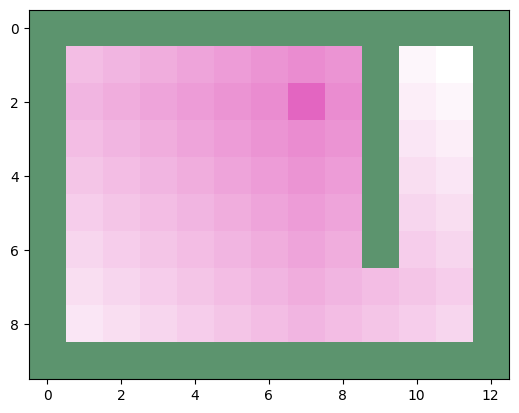

In [334]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex, to_rgb
cmap_grid = ListedColormap(["#D6D6D6", '#5C946E', '#FAE2DB', '#535865', "#F93943", "#E365C1"])
rgb_target = np.array(to_rgb("#E365C1"))
brighter_target =  to_hex(rgb_target + (1 - rgb_target) * 0.2)
cmap_smell = LinearSegmentedColormap.from_list("smell_gradiant", [brighter_target, "#ffffff"])

grid = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 5, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
])

smells = smell_map(grid)
print(smells)
fig, ax = plt.subplots()
colors = ["#D6D6D6", '#5C946E', '#FAE2DB', '#535865', "#F93943", "#E365C1"]
colors_rgb = np.array([to_rgb(c) for c in colors])
cmap_grid = ListedColormap(colors)
ax.imshow(colors_rgb[grid])
masked_smell = np.ma.masked_where(grid > 0, smells)
max_smell = np.max(masked_smell)
if np.isfinite(max_smell):
    ax.imshow(masked_smell, cmap=cmap_smell, vmin=0, vmax=np.max(masked_smell))
plt.show()


## The logics

This environment can execute three actions: 
* `move_forward`
* `turn_left`
* `turn_right` 

which may yield six possible outcomes:

* `stable` : the target remains at the same distance (only after `turn` actions)
* `bump` : the agent collided with a wall (only after `move_forward`)
* `increase_left`: the target got closer on the left of the agent
* `increase_front`: the target got closer in front of the agent
* `increase_right`: the target got closer on the right of the agent
* `decrease`: the target got farther or disappeared from the sensory field
* `eat`: the agent reached the target and ate it (only after `move_forward`)

Figure 1 show the three sensory areas `left` `front` et  `right`.

![Agent11](img/Figure_2_vision.svg)

_Figure 1: Distal sensory field_

In [324]:
# Actions
FORWARD = 0
TURN_LEFT = 2
TURN_RIGHT = 1

# Outcomes
STABLE = 0
BUMP = 1
INCREASE_LEFT = 2
INCREASE_RIGHT = 3
INCREASE_FRONT = 4
DECREASE = 5
EAT = 6

We define the environment class

In [325]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from ipywidgets import Button, HBox,VBox, Output
from IPython.display import display

BUMPING = 4
TARGET = 5
save_dir = "sav"
agent_color = "#1976D2"
colors = ["#D6D6D6", '#5C946E', '#FAE2DB', '#535865', "#F93943", "#E365C1"]
# Directions
LEFT = 0
DOWN = 1
RIGHT = 2
UP = 3
SMELL_FEEDBACK = np.array([
    [STABLE,   INCREASE_RIGHT, INCREASE_LEFT, INCREASE_FRONT], 
    [DECREASE, INCREASE_RIGHT, STABLE,         INCREASE_FRONT], 
    [DECREASE, STABLE,        INCREASE_LEFT, INCREASE_FRONT], 
    [DECREASE, DECREASE,      DECREASE,       INCREASE_FRONT] 
])

class Environment():
    def __init__(self, position, direction):
        self.grid = np.array([
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
        ])
        self.maze = self.grid.copy()
        self.position = np.array(position)  # Using NumPy array of shape (2)
        self.direction = direction
        self.colors = np.array([to_rgb(c) for c in colors])
        self.marker_size = 400
        self.marker_map = {LEFT: '<', DOWN: 'v', RIGHT: '>', UP: '^'}
        self.marker_color = agent_color
        self.directions = np.array([
            [0, -1],  # Left
            [1, 0],   # Down
            [0, 1],   # Right
            [-1, 0]   # Up
        ])
        self.previous_smell = 0       
        self.smell_grid = np.full(self.grid.shape, np.inf)

    def smell(self):
        """Return the smell feedback: 1: smell left, 2: smell right, 3: smell front"""
        smell_up_left = np.any(self.grid[:self.position[0]+1, :self.position[1]+1] == TARGET) 
        smell_up_right = np.any(self.grid[:self.position[0]+1, self.position[1]:] == TARGET) 
        smell_down_left = np.any(self.grid[self.position[0]:, :self.position[1]+1] == TARGET) 
        smell_down_right = np.any(self.grid[self.position[0]:, self.position[1]:] == TARGET) 
        # print(f"Smell up-left:{smell_up_left}, up-right:{smell_up_right}, down-left:{smell_down_left}, down-right:{smell_down_right}")
        smell_left = {LEFT: smell_down_left, DOWN: smell_down_right, RIGHT: smell_up_right, UP: smell_up_left}[self.direction]
        smell_right = {LEFT: smell_up_left, DOWN: smell_down_left, RIGHT: smell_down_right, UP: smell_up_right}[self.direction]
        smell = 2 * smell_left + smell_right 
        result = SMELL_FEEDBACK[self.previous_smell, smell]
        self.previous_smell = smell
        return result
    
    def outcome(self, action):
        """Update the grid. Return the outcome of the action."""
        result = STABLE

        if action == FORWARD:  
            target_position = self.position + self.directions[self.direction]
            if self.grid[tuple(target_position)] in [0, TARGET]:  # Don't bump in targets
                self.position[:] = target_position
            else:
                result = BUMP
                self.maze[tuple(target_position)] = BUMPING
        
        elif action == TURN_RIGHT:
            self.direction = {LEFT: UP, DOWN: LEFT, RIGHT: DOWN, UP: RIGHT}[self.direction]
        
        elif action == TURN_LEFT:
            self.direction = {LEFT: DOWN, DOWN: RIGHT, RIGHT: UP, UP: LEFT}[self.direction]
        
        elif action == FEEL_FRONT:
            feeling_position = self.position + self.directions[self.direction]
            if self.grid[tuple(feeling_position)] == 0:
                self.maze[tuple(feeling_position)] = FEELING_EMPTY
            else:
                result = BUMP
                self.maze[tuple(feeling_position)] = FEELING_WALL
        
        elif action == FEEL_LEFT:
            feeling_position = self.position + self.directions[(self.direction + 1) % 4]
            if self.grid[tuple(feeling_position)] == 0:
                self.maze[tuple(feeling_position)] = FEELING_EMPTY
            else:
                result = BUMP
                self.maze[tuple(feeling_position)] = FEELING_WALL
        
        elif action == FEEL_RIGHT:
            feeling_position = self.position + self.directions[self.direction - 1]
            if self.grid[tuple(feeling_position)] == 0:
                self.maze[tuple(feeling_position)] = FEELING_EMPTY
            else:
                result = BUMP
                self.maze[tuple(feeling_position)] = FEELING_WALL

        # Smell
        smell_feedback = self.smell()
        # Eeat
        if self.grid[self.position[0], self.position[1]] == TARGET:
            self.clear_target(self.position[0], self.position[1])
            # self.grid[self.position[0], self.position[1]] = 0
            # self.maze[self.position[0], self.position[1]] = 0
            result = EAT
        # If not bump then smell_feeback
        if not result:
            result = smell_feedback
        
        # print(f"Line: {self.position[0]}, Column: {self.position[1]}, direction: {self.direction}")
        return result  
    
    def display(self):
        """Display the grid in the notebook"""
        out.clear_output(wait=True)
        with out:
            fig, ax = plt.subplots()
            ax.imshow(colors_rgb[self.maze])
            plt.scatter(self.position[1], self.position[0], s=self.marker_size, marker=self.marker_map[self.direction], c=self.marker_color)
            masked_smell = np.ma.masked_where(self.grid > 0, self.smell_grid)
            if np.isfinite(np.max(masked_smell)):
                ax.imshow(masked_smell, cmap=cmap_smell, vmin=0, vmax=np.max(masked_smell))
            plt.show()
        def on_click(event):
            """Add or remove a target when the user clicks on the grid in widget mode"""
            if event.inaxes is ax and event.button == 1 and event.xdata is not None:
                c, l = round(event.xdata), round(event.ydata)
                if self.grid[l, c] == 0:
                    self.add_target(l, c)
                elif self.grid[l, c] == TARGET:
                    self.clear_target(l, c)
                ax.imshow(colors_rgb[self.maze])
                masked_smell = np.ma.masked_where(self.grid > 0, self.smell_grid)
                if np.isfinite(np.max(masked_smell)):
                    ax.imshow(masked_smell, cmap=cmap_smell, vmin=0, vmax=np.max(masked_smell))
        cid = fig.canvas.mpl_connect('button_press_event', on_click)
    
    def save(self, step):
        """Save the display as a PNG file"""
        fig, ax = plt.subplots()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        ax.imshow(colors_rgb[self.maze])
        masked_smell = np.ma.masked_where(self.grid > 0, self.smell_grid)
        if np.isfinite(np.max(masked_smell)):
            ax.imshow(masked_smell, cmap=cmap_smell, vmin=0, vmax=np.max(masked_smell))
        plt.scatter(self.position[1], self.position[0], s=self.marker_size, marker=self.marker_map[self.direction], c=self.marker_color)
        ax.text(self.grid.shape[1]-1.5, 0.2, f"{step:>3}", fontsize=12, color='White')
        plt.savefig(f"{save_dir}/{step:03}.png", bbox_inches='tight', pad_inches=0, transparent=True)
        plt.close(fig)
    
    def clear(self, clear):
        """Clear the grid display"""
        if clear:
            self.maze[:, :] = self.grid

    def add_target(self, l, c):
        """Insert a new target at position (l, c)"""
        self.grid[l, c] = TARGET
        self.maze[l, c] = TARGET
        self.smell_grid[:,:] = smell_map(self.grid)

    def clear_target(self, l, c):
        """Remove target at position (l, c)"""
        self.grid[l, c] = 0
        self.maze[l, c] = 0    
        self.smell_grid[:,:] = smell_map(self.grid)

# Let's demonstrate the agent

## Select the `widget` display mode

If your version of Python allows it, you can switch to `widget` display mode by uncommenting the line `%matplotlib widget` in the cell below.
This mode allows adding targets by clicking on the grid. 

You can return to `inLine` mode by uncommenting and runnin the line `%matplotlib inline`. 

In [326]:
# Mode widget pour pouvoir cliquer sur la grille pour insérer une cible
%matplotlib widget

# Mode inline ne permet pas d'ajouter des cibles en cliquant sur la grille
# %matplotlib inline

## Initialize the valences of interactions 

In [327]:
import ipywidgets as widgets
from IPython.display import display
# Définition des curseurs
slider_trn_left_stable = widgets.IntSlider(value=0, min=-20, max=10, description='Trn left stable', continuous_update=False)
slider_trn_left_left = widgets.IntSlider(value=5, min=-20, max=10, description='Trn left Left', continuous_update=False)
slider_trn_left_front = widgets.IntSlider(value=5, min=-20, max=10, description='Trn left front', continuous_update=False)
slider_trn_left_right = widgets.IntSlider(value=5, min=-20, max=10, description='Trn left right', continuous_update=False)
slider_trn_left_decrease = widgets.IntSlider(value=-10, min=-20, max=10, description='Trn left decrease', continuous_update=False)
vbox1 = widgets.VBox([slider_trn_left_stable, slider_trn_left_left, slider_trn_left_front, slider_trn_left_right, slider_trn_left_decrease])

slider_fwd_stable = widgets.IntSlider(value=-5, min=-20, max=10, description='Fwd stable', continuous_update=False)
slider_fwd_decrease = widgets.IntSlider(value=-10, min=-20, max=10, description='Fwd decrease', continuous_update=False)
slider_fwd_bump = widgets.IntSlider(value=-10, min=-20, max=10, description='Bump', continuous_update=False)
slider_eat = widgets.IntSlider(value=0, min=-20, max=10, description='Eat', continuous_update=False)
slider_fwd_left = widgets.IntSlider(value=5, min=-20, max=10, description='Fwd left', continuous_update=False)
slider_fwd_front = widgets.IntSlider(value=10, min=-20, max=10, description='Fwd front', continuous_update=False)
slider_fwd_right = widgets.IntSlider(value=5, min=-20, max=10, description='Fwd right', continuous_update=False)
vbox2 = widgets.VBox([slider_fwd_stable, slider_fwd_left, slider_fwd_front, slider_fwd_right, slider_fwd_decrease, slider_fwd_bump, slider_eat])

slider_trn_right_stable = widgets.IntSlider(value=0, min=-20, max=10, description='Trn right stable', continuous_update=False)
slider_trn_right_left = widgets.IntSlider(value=5, min=-20, max=10, description='Trn right Left', continuous_update=False)
slider_trn_right_front = widgets.IntSlider(value=5, min=-20, max=10, description='Trn right front', continuous_update=False)
slider_trn_right_right = widgets.IntSlider(value=5, min=-20, max=10, description='Trn right right', continuous_update=False)
slider_trn_right_decrease = widgets.IntSlider(value=-10, min=-20, max=10, description='Trn right decrease', continuous_update=False)
vbox3 = widgets.VBox([slider_trn_right_stable, slider_trn_right_left, slider_trn_right_front, slider_trn_right_right, slider_trn_right_decrease])

# Affichage des curseurs
display(widgets.HBox([vbox1, vbox2, vbox3]))

## Initialize the exeriment

In [328]:
# Instanciate the environment
e = Environment([6, 4], UP)

# Instanciate the agent 
interactions = [
    Interaction(FORWARD, STABLE, slider_fwd_stable.value),
    Interaction(FORWARD, BUMP, slider_fwd_bump.value),
    Interaction(FORWARD, INCREASE_LEFT, slider_fwd_left.value),
    Interaction(FORWARD, INCREASE_RIGHT, slider_fwd_right.value),
    Interaction(FORWARD, INCREASE_FRONT, slider_fwd_front.value),
    Interaction(FORWARD, DECREASE, slider_fwd_decrease.value),
    Interaction(FORWARD, EAT, slider_eat.value),
    Interaction(TURN_LEFT, STABLE, slider_trn_left_stable.value),
    Interaction(TURN_LEFT, INCREASE_LEFT, slider_trn_left_left.value),
    Interaction(TURN_LEFT, INCREASE_RIGHT, slider_trn_left_right.value),
    Interaction(TURN_LEFT, INCREASE_FRONT, slider_trn_left_front.value),
    Interaction(TURN_LEFT, DECREASE, slider_trn_left_decrease.value),
    Interaction(TURN_RIGHT, STABLE, slider_trn_right_stable.value),
    Interaction(TURN_RIGHT, INCREASE_LEFT, slider_trn_right_left.value),
    Interaction(TURN_RIGHT, INCREASE_RIGHT, slider_trn_right_right.value),
    Interaction(TURN_RIGHT, INCREASE_FRONT, slider_trn_right_front.value),
    Interaction(TURN_RIGHT, DECREASE, slider_trn_right_decrease.value),
]
a = Agent(interactions)

# Initialize the experiment
step = 0
outcome = 0
out = Output()
e.display()
display(out)

Output()

## Add a targets

In [329]:
# Add a new target at the specified (line, column)
e.add_target(3, 6)
e.display()

You can add more targets at the position `[ligne, colonne]` of your choice by modifying the cell above.

## Run the agent step by step

We run the agent one step at a time, using `Ctrl+Enter` on the next cell:

In [330]:
print(f"Step: {step}")
step += 1
action = a.action(outcome)
e.display()
e.clear(True)
# e.save(step)  # Sauvegarde le fichier image qui servira au gif
outcome = e.outcome(action)
a.proposed_df

Step: 0


,activated,weight,actions,intention,valence,decision,length,pre,proclivity
0,,0,0,00,-5,0,1,,0
1,,0,1,10,0,1,1,,0
2,,0,2,20,0,2,1,,0


# Run the agent in a loop

Make sure we are in the `inLine` display mode otherwise the animation does not work.

In [331]:
# Mode inline mode does not allow adding a target by clicking on the figure
%matplotlib inline

Choose the steps and the positions of new targets to insert in `target_steps` et `target_positions`.

In [332]:
# The steps when new targets are inserted
target_steps = [0, 30, 60, 90, 120, 150, 180]
# The positions [line, column] where the new targets are inserted. The keys must correspond to the steps above.
target_positions = {0:[3, 6], 30: [7, 10], 60:[2, 2], 90:[4, 10], 120:[8, 4], 150:[6, 7], 180:[3, 2]}

Run the simulation

In [333]:
# Deactivate trace
trace = False

# Instanciate the environment
e = Environment([6, 4], UP)
# Initialize the agent
a = Agent(interactions)
outcome = 0

# Display
out = Output()
e.display()
display(out)
for step in range(400):
    if step in target_steps:
        e.add_target(target_positions[step][0], target_positions[step][1])
    action = a.action(outcome)
    e.display()
    # e.save(step)  # Save a screenshot 
    e.clear(True)
    outcome = e.outcome(action)

Output()

Observe that, after catching a few targets, the agent learns to reach the target efficiently by following a stair-case trajectory until it aligns itself with the target moves straigt to it. 

# Assignment

Modify the valences of the interactions using the cursors above, and rerun the agent to observe its new behavior. 

## 1. The agent who smacked its head against the wall

Give a positive valence to the `bump` interaction. 
Observe that the agent will place itself in front of a wall and keep bumping into it as if it enjoyed it!

## 2. The agent who beat around the bush

Choose the valences to make the agent turn around the target without actually reaching it.

## 3. The agent who ran

Choose the valences to make the agent go away from the target. 
